In [61]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np # linear algebra
import pandas as pd # data processing

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest,chi2,f_classif
from sklearn.ensemble import RandomForestClassifier,VotingClassifier,AdaBoostClassifier,GradientBoostingClassifier,BaggingClassifier
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

import pickle
import string

# Text Processing libraries
import nltk
nltk.download('punkt_tab')
from nltk.stem import PorterStemmer

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [62]:
data = pd.read_csv('/content/Suicide_Detection.csv')
data.head()

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [63]:
data.shape

(232074, 3)

In [64]:
df = data.sample(n=10000, random_state=42)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 74414 to 224640
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   text        10000 non-null  object
 2   class       10000 non-null  object
dtypes: int64(1), object(2)
memory usage: 312.5+ KB


In [66]:
df['Unnamed: 0'].is_unique

True

In [67]:
df.drop(columns = 'Unnamed: 0',inplace=True)

In [68]:
df.isnull().sum()

,0
text,0
class,0


In [69]:
df.duplicated().sum()

np.int64(0)

class
non-suicide    5048
suicide        4952
Name: count, dtype: int64


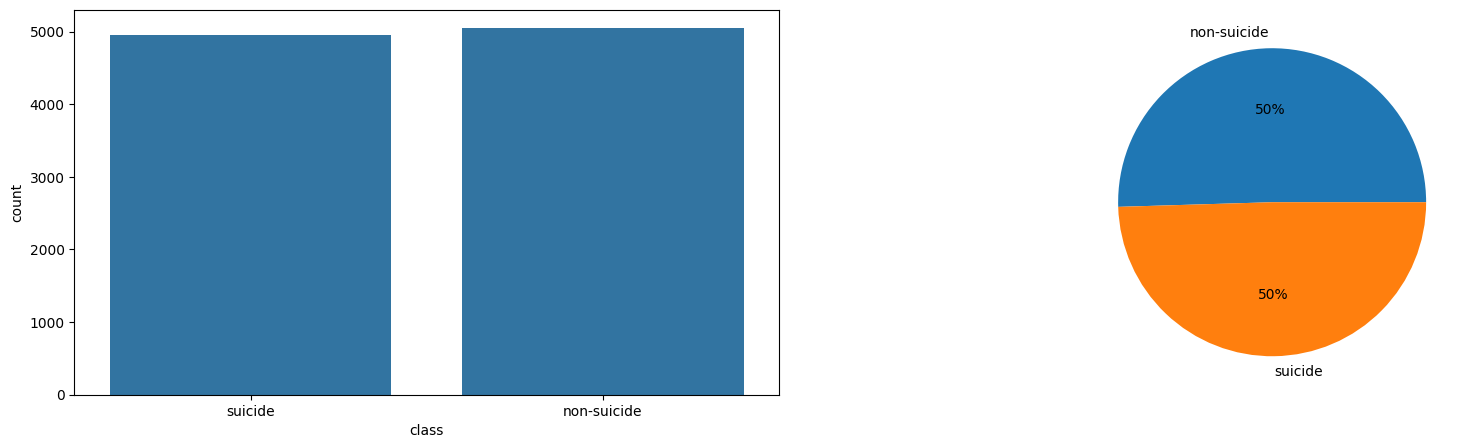

In [70]:
classCnt = df['class'].value_counts()
print(classCnt)

plt.figure(figsize=((20,5)))

plt.subplot(1,2,1)
sns.countplot(df,x='class')

plt.subplot(1,2,2)
plt.pie(classCnt,labels = classCnt.index,autopct='%.0f%%')

plt.show()

In [71]:
df['text']= df['text'].str.lower()

In [72]:
df['text'] = df['text'].str.replace(r'[^\w\s]+', '',regex = True)

In [73]:
nltk.download('stopwords')
import nltk
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [74]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

In [75]:
df['text'] = df['text'].apply(lambda x:nltk.word_tokenize(x))

In [76]:
ps = PorterStemmer()
df['text'] = df['text'].apply(lambda x : [ps.stem(i) for i in x])

In [77]:
df['text']=df['text'].apply(lambda x : ' '.join(x))

In [78]:

# Assuming your DataFrame is named df and the column is named 'label'
df['class'] = df['class'].replace({'suicide': 'depressed', 'non-suicide': 'non depressed'}, regex=True)


In [79]:
df.head()

,text,class
74414,dont know7 month self harm free urg get strong...,depressed
149516,start becom rich start compani becom 16 afford...,non-depressed
12484,poem haiku umegamedev hi hello hello stop fuck...,non-depressed
14043,ive honestli got idea anymoreit feel everyon f...,depressed
30673,ever cri like think unfair life cri cant cri e...,non-depressed


In [80]:
# Saved the cleaned dataset.
df.to_csv('file1.csv')

In [81]:
dfnew = pd.read_csv('file1.csv')
dfnew.head()

,Unnamed: 0,text,class
0,74414,dont know7 month self harm free urg get strong...,depressed
1,149516,start becom rich start compani becom 16 afford...,non-depressed
2,12484,poem haiku umegamedev hi hello hello stop fuck...,non-depressed
3,14043,ive honestli got idea anymoreit feel everyon f...,depressed
4,30673,ever cri like think unfair life cri cant cri e...,non-depressed


In [82]:
dfnew.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   text        9999 non-null   object
 2   class       10000 non-null  object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


In [83]:
ind = dfnew[dfnew['text'].isnull()].index

In [84]:
df.iloc[ind]

,text,class
102482,,depressed


In [85]:
dfnew.dropna(inplace=True)

In [86]:
x,y = dfnew['text'],dfnew['class']

In [87]:
vectorizer = TfidfVectorizer(min_df=50,max_features=5000)
x =  vectorizer.fit_transform(x).toarray()

In [88]:
# Save the model
with open('tfidf1.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [89]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=5)

In [90]:
X_train.shape,X_test.shape

((6999, 1320), (3000, 1320))

## Naive Bayes (Voting Classifier)

In [91]:
nb = GaussianNB()
nb2 = BernoulliNB()
nb3 = MultinomialNB()
VotingClassifiers = VotingClassifier(estimators=[('GaussianNB', nb),('BernoulliNB',nb2), ('MultinomialNB', nb3)], voting = 'soft')
VotingClassifiers.fit(X_train, y_train)
print('Training score:',VotingClassifiers.score(X_train, y_train))
print('Testing score:',VotingClassifiers.score(X_test,y_test))

Training score: 0.899271324474925
Testing score: 0.8753333333333333


               precision    recall  f1-score   support

    depressed       0.87      0.87      0.87      1458
non-depressed       0.88      0.88      0.88      1542

     accuracy                           0.88      3000
    macro avg       0.88      0.88      0.88      3000
 weighted avg       0.88      0.88      0.88      3000



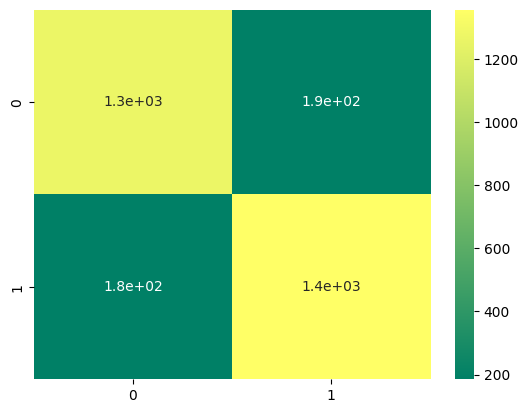

In [92]:
y_act=y_test
y_pred=VotingClassifiers.predict(X_test)
sns.heatmap(confusion_matrix(y_act,y_pred),annot=True,cmap='summer')
print(classification_report(y_act,y_pred))

## Random Forest

In [93]:
classifiers = RandomizedSearchCV(RandomForestClassifier(),{'n_estimators':[4,5],'criterion':['entropy'],
                                                      'max_depth':range(1,4),'min_samples_split':range(2,5)},random_state=12)
classifiers.fit(X_train, y_train)
print('Training score:',classifiers.score(X_train, y_train))
print('Testing score:',classifiers.score(X_test,y_test))
print(classifiers.best_estimator_)

Training score: 0.7982568938419774
Testing score: 0.801
RandomForestClassifier(criterion='entropy', max_depth=3, min_samples_split=3,
                       n_estimators=5)


               precision    recall  f1-score   support

    depressed       0.84      0.73      0.78      1458
non-depressed       0.77      0.87      0.82      1542

     accuracy                           0.80      3000
    macro avg       0.81      0.80      0.80      3000
 weighted avg       0.81      0.80      0.80      3000



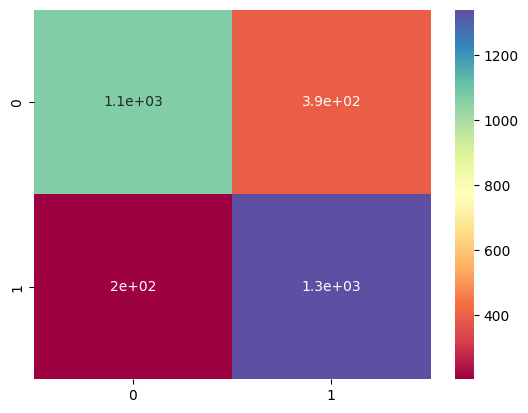

In [94]:
y_act=y_test
y_pred=classifiers.predict(X_test)
sns.heatmap(confusion_matrix(y_act,y_pred),annot=True,cmap='Spectral')
print(classification_report(y_act,y_pred))

## Decision Tree

In [95]:
model2 = DecisionTreeClassifier(criterion='gini',splitter='random',min_samples_leaf=70,max_depth=4,random_state=0)
model2.fit(X_train, y_train)
print(model2.score(X_train, y_train))
print(model2.score(X_test,y_test))

0.7485355050721532
0.7526666666666667


               precision    recall  f1-score   support

    depressed       0.77      0.70      0.73      1458
non-depressed       0.74      0.80      0.77      1542

     accuracy                           0.75      3000
    macro avg       0.75      0.75      0.75      3000
 weighted avg       0.75      0.75      0.75      3000



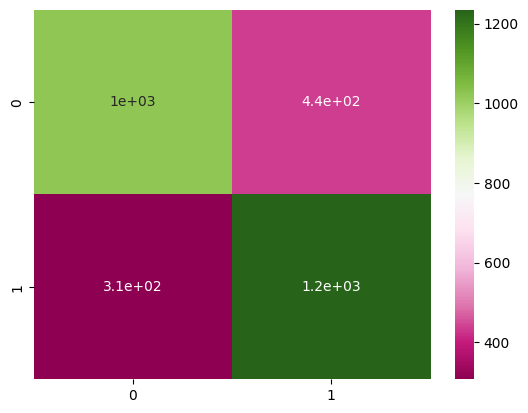

In [96]:
y_act=y_test
y_pred=model2.predict(X_test)
sns.heatmap(confusion_matrix(y_act,y_pred),annot=True,cmap='PiYG')
print(classification_report(y_act,y_pred))

## Gradient Boosting

In [97]:
model3 = RandomizedSearchCV(GradientBoostingClassifier(),{"learning_rate": range(3,5),
                "max_depth":[200],"max_features":range(6,10,2),
                 "n_estimators":[10]},random_state=8,n_jobs=-1)
model3.fit(X_train,y_train)
print('Training score:',model3.score(X_train,y_train))
print('Testing score:',model3.score(X_test,y_test))
model3.best_params_

Training score: 0.6062294613516217
Testing score: 0.5993333333333334


{'n_estimators': 10, 'max_features': 6, 'max_depth': 200, 'learning_rate': 3}

               precision    recall  f1-score   support

    depressed       0.65      0.37      0.48      1458
non-depressed       0.58      0.81      0.68      1542

     accuracy                           0.60      3000
    macro avg       0.62      0.59      0.58      3000
 weighted avg       0.61      0.60      0.58      3000



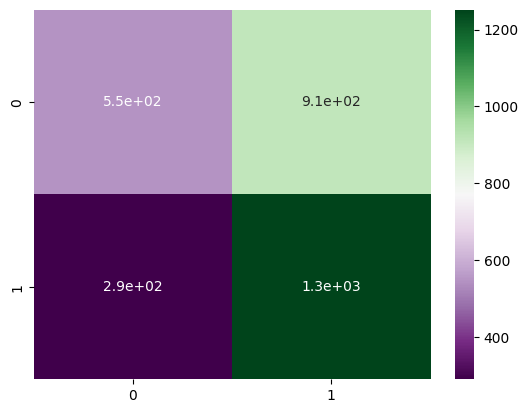

In [98]:
#confusion matrix and classification report
y_act=y_test
y_pred=model3.predict(X_test)
sns.heatmap(confusion_matrix(y_act,y_pred),annot=True,cmap='PRGn')
print(classification_report(y_act,y_pred))

## XG Boost

## K-Nearest Neighbour

In [99]:
model = RandomizedSearchCV(KNeighborsClassifier(),{'n_neighbors':[8],'metric':['manhattan','minkowski','cosine','tanimoto'],
                                                   'p':[1,2]},random_state=42,n_jobs=-1)
model.fit(X_train, y_train)
print('Training score:',model.score(X_train, y_train))
print('Testing score:',model.score(X_test,y_test))
print(model.best_estimator_)

Training score: 0.8805543649092727
Testing score: 0.848
KNeighborsClassifier(metric='cosine', n_neighbors=8, p=1)


               precision    recall  f1-score   support

    depressed       0.83      0.87      0.85      1458
non-depressed       0.87      0.83      0.85      1542

     accuracy                           0.85      3000
    macro avg       0.85      0.85      0.85      3000
 weighted avg       0.85      0.85      0.85      3000



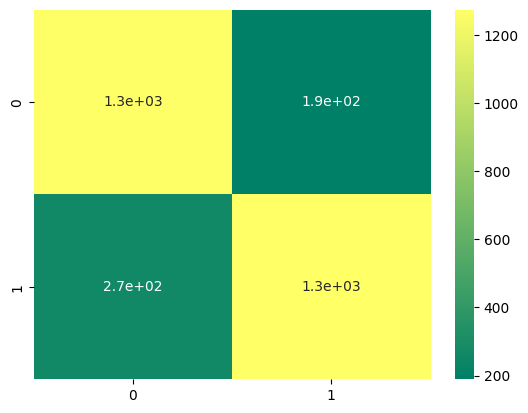

In [100]:
y_act = y_test
y_pred = model.predict(X_test)
sns.heatmap(confusion_matrix(y_act,y_pred),annot=True,cmap='summer')
print(classification_report(y_act,y_pred))

# Conclusion

- From the above we can say that out of all models, **Naive Bayes (Voting Classifier)**  is best fit model for the dataset.
+ Training score: 0.899271324474925
* Testing score: 0.8753333333333333